
# Knowledge Graphs and Semantic Technologies -- ML4KG Tutorial


Import libraries

In [2]:
# you need to install pykeen beforehand, see https://pykeen.readthedocs.io/en/stable/installation.html 
import os
import numpy as np
import pandas as pd
import pykeen
import seaborn
import zipfile
import io
from pykeen import datasets
from pykeen.pipeline import pipeline
from rdflib import Graph, ConjunctiveGraph, Literal, BNode, Namespace, RDF, URIRef, RDFS
import urllib.parse
import sys
import pathlib

sys.modules["pathlib._local"] = pathlib
if os.name == 'nt':
   pathlib.PosixPath = pathlib.WindowsPath
else:
   pathlib.WindowsPath = pathlib.PosixPath

import requests
from pykeen import triples

# 1. Dataset exploration


In [4]:
import rdflib

g = rdflib.Graph()
g.parse("./data/pg_final_ont.ttl", format="turtle")

<Graph identifier=N94fe196ed34c4c64b00a0b3b39a0548b (<class 'rdflib.graph.Graph'>)>

In [5]:
triples = []
for s, p, o in g:
    if isinstance(o, rdflib.term.URIRef):  # ignore literals for now
        triples.append((str(s), str(p), str(o)))

In [6]:
entities = list(set([s for s,_,_ in triples] + [o for _,_,o in triples]))
relations = list(set([p for _,p,_ in triples]))

entity2id = {e:i for i,e in enumerate(entities)}
relation2id = {r:i for i,r in enumerate(relations)}

triples_id = [(entity2id[s], relation2id[p], entity2id[o]) for s,p,o in triples]

In [7]:
triples_id[:5]

[(309, 15, 161), (211, 1, 21), (45, 38, 273), (1, 18, 415), (191, 15, 268)]

### Exercise 1

List the unique subject and object entities found in the dataset. Then list all of the relationships that link the entities (note that some entities are not linked). Create an RDF version of the dataset, using your own namespaces, and save is as a ttl file. 

Using SPARQL, answer the following questions : 
1. How many instances per class? Use ORDER BY to show the most popular class
2. What is the most common relation per each class?

In [9]:
# 1 List unique Subjects and Objects
subjects = set([s for s, _, _ in triples])
objects  = set([o for _, _, o in triples])

print(len(subjects))
print(len(objects))

print(list(subjects)[:5])
print(list(objects)[:5])


# 2 List predicates
relations = set([p for _, p, _ in triples])
print(len(relations))

584
467
['https://w3id.org/hi-ontology#EducationDomain', 'nffe78800543f4d05b414a246c2baee4fb21', 'https://w3id.org/hi-ontology#SpreadingActivation', 'https://w3id.org/hi-ontology#Data_GazeTrackingStream', 'https://w3id.org/hi-ontology#TrustCalibrationExperiment']
['https://w3id.org/hi-ontology#EducationDomain', 'https://w3id.org/hi-ontology#SpreadingActivation', 'https://w3id.org/hi-ontology#Data_GazeTrackingStream', 'https://w3id.org/hi-ontology#TrustCalibrationExperiment', 'https://w3id.org/hi-ontology#ArchivalFootageAISystem']
48


In [10]:
# 3 Create RDF version and Save as ttl
from rdflib import Graph, URIRef

g_new = Graph()

for s, p, o in triples:
    g_new.add((URIRef(s), URIRef(p), URIRef(o)))

g_new.serialize("pg_reconstructed.ttl", format="turtle")

<Graph identifier=Nf739c0388aac468591a0bad4b6cec165 (<class 'rdflib.graph.Graph'>)>

In [11]:
# 4 Number of Subjects per Property - WITHOUT FILTER
answer = list(g.query("""
SELECT ?p (COUNT(DISTINCT ?s) as ?num_subj)
WHERE {
  ?s ?p ?o .
}
GROUP BY ?p
ORDER BY DESC(?num_subj)
"""))

for p, n in answer:
    print(g.namespace_manager.normalizeUri(p), int(n))

rdf:type 570
rdfs:label 437
rdfs:comment 85
rdfs:range 54
rdfs:domain 54
hi:requiresCapability 48
hi:hasCapability 44
hi:realizesTask 35
hi:hasInteractionEpisode 34
hi:performedBy 33
hi:operatesInContext 32
hi:hasAgentInvolved 30
hi:hasInputData 29
hi:allowsTask 29
hi:hasOutputData 28
hi:towardsGoal 28
hi:performsExecution 23
hi:requiresTask 21
hi:hasDomain 21
hi:hasGoal 21
hi:hasHITeam 21
hi:hasMember 21
hi:isInfluencedBy 18
hi:hasMetricTested 17
rdf:rest 13
rdfs:subClassOf 13
rdf:first 13
hi:usesModel 12
hi:evaluatedBy 11
hi:hasMethod 11
hi:hasExperiment 10
hi:hasNullHypothesis 7
hi:hasAlternativeHypothesis 7
hi:hasAutonomyLevel 6
hi:hasContext 6
hi:hasAgreementLevel 6
hi:hasOutcomeQuality 6
hi:hasExplainabilityLevel 6
owl:onProperty 5
owl:minQualifiedCardinality 5
owl:onClass 5
owl:inverseOf 4
hi:hasMetricConcept 4
owl:unionOf 3
hi:hasInfluenceOn 3
owl:propertyChainAxiom 3
rdfs:subPropertyOf 2
dc:license 1
hi:makesDecision 1
hi:providesExplanation 1
rdfs:seeAlso 1
dc:description 1
v

In [12]:
# 4 Number of Subjects per Property - WITH FILTER
answer = list(g.query("""
SELECT ?p (COUNT(DISTINCT ?s) as ?num_subj)
WHERE {
  ?s ?p ?o .
  FILTER(?rel != rdf:type &&
             ?rel != rdfs:label &&
             ?rel != rdfs:domain &&
             ?rel != rdfs:range &&
             ?rel != rdfs:comment)
}
GROUP BY ?p
ORDER BY DESC(?num_subj)
"""))

for p, n in answer:
    print(g.namespace_manager.normalizeUri(p), int(n))

In [13]:
# 5 Most common relation
classes = [row[0] for row in g.query("""
SELECT DISTINCT ?class
WHERE {
  ?x rdf:type ?class .
}
""")]

for cls in classes:
    q = f"""
    SELECT ?rel (COUNT(*) AS ?freq)
    WHERE {{
      ?x rdf:type <{cls}> .
      ?x ?rel ?z .
      FILTER(?rel != rdf:type &&
             ?rel != rdfs:label &&
             ?rel != rdfs:domain &&
             ?rel != rdfs:range &&
             ?rel != rdfs:comment
      )
    }}
    GROUP BY ?rel
    ORDER BY DESC(?freq)
    LIMIT 1
    """

    result = list(g.query(q))
    class_label = g.namespace_manager.normalizeUri(cls)

    if result:
        rel, freq = result[0]
        rel_label = g.namespace_manager.normalizeUri(rel)
        print(class_label, "->", rel_label, int(freq))

owl:Ontology -> owl:imports 1
owl:ObjectProperty -> owl:inverseOf 4
owl:Class -> rdfs:subClassOf 16
owl:Restriction -> owl:onProperty 5
owl:NamedIndividual -> hi:hasCapability 91
hi:ArtificialAgent -> hi:hasCapability 59
hi:TaskExecution -> hi:performedBy 49
hi:Context -> hi:hasInfluenceOn 3
hi:UseCase -> hi:hasDomain 21
hi:Capability -> hi:allowsTask 38
foaf:Person -> hi:hasCapability 26
hi:HumanAgent -> hi:hasCapability 32
hi:HITeam -> hi:hasMember 45
hi:Model -> hi:hasMethod 12
hi:Task -> hi:requiresCapability 82
hi:Interaction -> hi:hasAgentInvolved 64
hi:Domain -> rdfs:seeAlso 1
hi:Evaluation -> hi:hasExperiment 20
hi:Experiment -> hi:hasMetricTested 19
hi:Goal -> hi:requiresTask 39
schema1:Organization -> schema1:name 1


### Cleaning the dataset

In [15]:
remove_preds = {
    "http://www.w3.org/1999/02/22-rdf-syntax-ns#type",
    "http://www.w3.org/2000/01/rdf-schema#label",
    "http://www.w3.org/2000/01/rdf-schema#comment",
    "http://www.w3.org/2000/01/rdf-schema#domain",
    "http://www.w3.org/2000/01/rdf-schema#range",
}

filtered_triples = [
    (s, p, o)
    for (s, p, o) in triples
    if p not in remove_preds
]

# 2. Defining train and test datasets


In [17]:
from pykeen.triples import TriplesFactory
import numpy as np

triples_array = np.array(filtered_triples, dtype=str)

tf = TriplesFactory.from_labeled_triples(triples_array)

train_80, test_20 = tf.split([0.8, 0.2], random_state=42)
train_90, test_10 = tf.split([0.9, 0.1], random_state=42)

In [18]:
print("Train:", train_80.mapped_triples.shape)
print("Test:", test_20.mapped_triples.shape)

Train: torch.Size([720, 3])
Test: torch.Size([180, 3])


In [19]:
print("Train:", train_90.mapped_triples.shape)
print("Test:", test_10.mapped_triples.shape)

Train: torch.Size([810, 3])
Test: torch.Size([90, 3])


# 3. Training and testing the model

PyKEEN has implemented several Knoweldge Graph Embedding models (TransE, ComplEx, DistMult, HolE, etc.). We will use the ComplEx model with default values for this tutorial.

You can find the list of all implemented models in the documentation: https://pykeen.readthedocs.io/en/stable/reference/models.html

Understanding the parameters:

- dimensions : the dimensionality of the embedding space
- negative_sampler : the negative samplic strategy, here set to default (not used in arguments).
- batch_size : the number of batches in which the training set is split during the training loop. If you are having into low memory issues than settings this to a higher number may help.
- epochs : the number of epochs to train the model for.
- optimizer : the Adam optimizer, with a learning rate of $1e-3$ set via the <i>optimizer_kwarg</i>.
- loss : pairwise loss, with a margin of $0.5$ set via the <i>loss_kwarg</i>.
- regularizer :  regularization with $p=2$, i.e. $l_2$ regularization. $\lambda$ = $1e-5$, set via the <i>regularizer_kwarg</i>.

### 1 Experiment with Dataset

In [24]:
# 80/20 split, 200 epochs, 150 embeddings, 1e-3
pipeline_result = pipeline(
    model='ComplEx',
    training=train_80,
    testing=test_20,
    random_seed=42,
    
    epochs=200,
    dimensions=150,
    optimizer='adam',
    optimizer_kwargs={'lr':1e-3},
    loss='pairwisehinge', 
    regularizer='LP', 
    regularizer_kwargs={'p':3, 'weight':1e-5}, 
    
    negative_sampler='basic',
    negative_sampler_kwargs=dict(
        filtered=True,
    )
)
print(pipeline_result.get_metric('mrr'))

No cuda devices were available. The model runs on CPU


Training epochs on cpu:   0%|          | 0/200 [00:00<?, ?epoch/s]

Training batches on cpu:   0%|          | 0.00/3.00 [00:00<?, ?batch/s]

Training batches on cpu:   0%|          | 0.00/3.00 [00:00<?, ?batch/s]

Training batches on cpu:   0%|          | 0.00/3.00 [00:00<?, ?batch/s]

...

Training batches on cpu:   0%|          | 0.00/3.00 [00:00<?, ?batch/s]

Training batches on cpu:   0%|          | 0.00/3.00 [00:00<?, ?batch/s]

Evaluating on cpu:   0%|          | 0.00/180 [00:00<?, ?triple/s]

INFO:pykeen.evaluation.evaluator:Evaluation took 0.14s seconds


0.019420647993683815


In [25]:
# 80/20 split, 300 epochs, 150 embeddings, 1e-3
pipeline_result1 = pipeline(
    model='ComplEx',
    training=train_80,
    testing=test_20,
    random_seed=42,
    
    epochs=300,
    dimensions=150,
    optimizer='adam',
    optimizer_kwargs={'lr':1e-3},
    loss='pairwisehinge', 
    regularizer='LP', 
    regularizer_kwargs={'p':3, 'weight':1e-5}, 
    
    negative_sampler='basic',
    negative_sampler_kwargs=dict(
        filtered=True,
    )
)
print(pipeline_result1.get_metric('mrr'))

INFO:pykeen.pipeline.api:Using device: None
INFO:pykeen.nn.representation:Inferred unique=False for Embedding(
  (regularizer): LpRegularizer()
)
INFO:pykeen.nn.representation:Inferred unique=False for Embedding(
  (regularizer): LpRegularizer()
)


Training epochs on cpu:   0%|          | 0/300 [00:00<?, ?epoch/s]

Training batches on cpu:   0%|          | 0.00/3.00 [00:00<?, ?batch/s]

Training batches on cpu:   0%|          | 0.00/3.00 [00:00<?, ?batch/s]

Training batches on cpu:   0%|          | 0.00/3.00 [00:00<?, ?batch/s]

...

Training batches on cpu:   0%|          | 0.00/3.00 [00:00<?, ?batch/s]

Training batches on cpu:   0%|          | 0.00/3.00 [00:00<?, ?batch/s]

Evaluating on cpu:   0%|          | 0.00/180 [00:00<?, ?triple/s]

INFO:pykeen.evaluation.evaluator:Evaluation took 0.11s seconds


0.019508937373757362


In [26]:
# 80/20 split, 300 epochs, 200 embeddings, 1e-3
pipeline_result2 = pipeline(
    model='ComplEx',
    training=train_80,
    testing=test_20,
    random_seed=42,
    
    epochs=300,
    dimensions=200,
    optimizer='adam',
    optimizer_kwargs={'lr':1e-3},
    loss='pairwisehinge', 
    regularizer='LP', 
    regularizer_kwargs={'p':3, 'weight':1e-5}, 
    
    negative_sampler='basic',
    negative_sampler_kwargs=dict(
        filtered=True,
    )
)
print(pipeline_result2.get_metric('mrr'))

INFO:pykeen.pipeline.api:Using device: None
INFO:pykeen.nn.representation:Inferred unique=False for Embedding(
  (regularizer): LpRegularizer()
)
INFO:pykeen.nn.representation:Inferred unique=False for Embedding(
  (regularizer): LpRegularizer()
)


Training epochs on cpu:   0%|          | 0/300 [00:00<?, ?epoch/s]

Training batches on cpu:   0%|          | 0.00/3.00 [00:00<?, ?batch/s]

Training batches on cpu:   0%|          | 0.00/3.00 [00:00<?, ?batch/s]

Training batches on cpu:   0%|          | 0.00/3.00 [00:00<?, ?batch/s]

...

Training batches on cpu:   0%|          | 0.00/3.00 [00:00<?, ?batch/s]

Training batches on cpu:   0%|          | 0.00/3.00 [00:00<?, ?batch/s]

Evaluating on cpu:   0%|          | 0.00/180 [00:00<?, ?triple/s]

INFO:pykeen.evaluation.evaluator:Evaluation took 0.13s seconds


0.019508937373757362


In [27]:
# 80/20 split, 200 epochs, 150 embeddings, 5e-4
pipeline_result3 = pipeline(
    model='ComplEx',
    training=train_80,
    testing=test_20,
    random_seed=42,
    
    epochs=200,
    dimensions=150,
    optimizer='adam',
    optimizer_kwargs={'lr':5e-4},
    loss='pairwisehinge', 
    regularizer='LP', 
    regularizer_kwargs={'p':3, 'weight':1e-5}, 
    
    negative_sampler='basic',
    negative_sampler_kwargs=dict(
        filtered=True,
    )
)
print(pipeline_result3.get_metric('mrr'))

INFO:pykeen.pipeline.api:Using device: None
INFO:pykeen.nn.representation:Inferred unique=False for Embedding(
  (regularizer): LpRegularizer()
)
INFO:pykeen.nn.representation:Inferred unique=False for Embedding(
  (regularizer): LpRegularizer()
)


Training epochs on cpu:   0%|          | 0/200 [00:00<?, ?epoch/s]

Training batches on cpu:   0%|          | 0.00/3.00 [00:00<?, ?batch/s]

Training batches on cpu:   0%|          | 0.00/3.00 [00:00<?, ?batch/s]

Training batches on cpu:   0%|          | 0.00/3.00 [00:00<?, ?batch/s]

...

Training batches on cpu:   0%|          | 0.00/3.00 [00:00<?, ?batch/s]

Training batches on cpu:   0%|          | 0.00/3.00 [00:00<?, ?batch/s]

Evaluating on cpu:   0%|          | 0.00/180 [00:00<?, ?triple/s]

INFO:pykeen.evaluation.evaluator:Evaluation took 0.11s seconds


0.01834670640528202


In [28]:
# 90/10 split, 300 epochs, 150 embeddings, 1e-3
pipeline_result4 = pipeline(
    model='ComplEx',
    training=train_90,
    testing=test_10,
    random_seed=42,
    
    epochs=200,
    dimensions=150,
    optimizer='adam',
    optimizer_kwargs={'lr':5e-4},
    loss='pairwisehinge', 
    regularizer='LP', 
    regularizer_kwargs={'p':3, 'weight':1e-5}, 
    
    negative_sampler='basic',
    negative_sampler_kwargs=dict(
        filtered=True,
    )
)
print(pipeline_result4.get_metric('mrr'))

INFO:pykeen.pipeline.api:Using device: None
INFO:pykeen.nn.representation:Inferred unique=False for Embedding(
  (regularizer): LpRegularizer()
)
INFO:pykeen.nn.representation:Inferred unique=False for Embedding(
  (regularizer): LpRegularizer()
)


Training epochs on cpu:   0%|          | 0/200 [00:00<?, ?epoch/s]

Training batches on cpu:   0%|          | 0.00/4.00 [00:00<?, ?batch/s]

Training batches on cpu:   0%|          | 0.00/4.00 [00:00<?, ?batch/s]

Training batches on cpu:   0%|          | 0.00/4.00 [00:00<?, ?batch/s]

...

Training batches on cpu:   0%|          | 0.00/4.00 [00:00<?, ?batch/s]

Training batches on cpu:   0%|          | 0.00/4.00 [00:00<?, ?batch/s]

Evaluating on cpu:   0%|          | 0.00/90.0 [00:00<?, ?triple/s]

INFO:pykeen.evaluation.evaluator:Evaluation took 0.08s seconds


0.021432777866721153


<Axes: title={'center': 'Losses Plot'}, xlabel='Epoch', ylabel='marginranking Loss'>

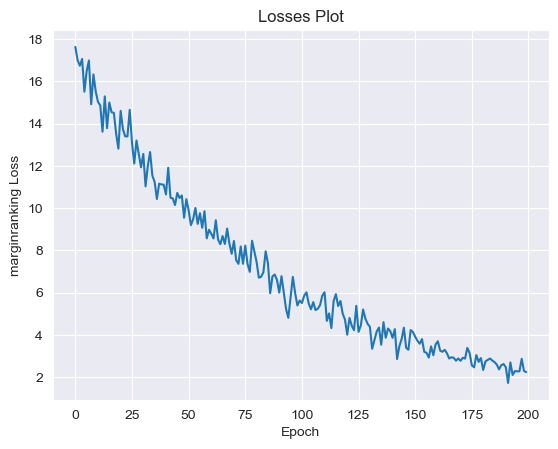

In [29]:
pipeline_result3.plot_losses()

<Axes: title={'center': 'Losses Plot'}, xlabel='Epoch', ylabel='marginranking Loss'>

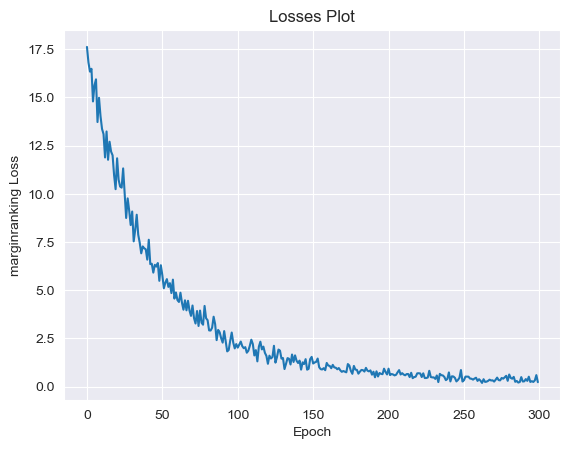

In [30]:
pipeline_result1.plot_losses()

In [31]:
# Save Best Model
import torch

torch.save(pipeline_result3.model, './data/best_model.pkl')

# 4. Evaluating the Model

### Metrics

We can now get some evaluation metrics for our model, they were already computed during evaluation time as part of the pipeline, and print them out.

We are going to use the following evaluation metrics:
- <i>mrr</i> (mean reciprocal rank) : this function computes the mean of the reciprocal of elements of a vector of rankings ranks
- <i>hits_at_n</i> : this function computes how many elements of a vector of rankings ranks make it to the $top_n$ positions.

NB : The choice of which _N_ makes more sense depends on the application and the size of the dataset.

In [35]:
results = pd.DataFrame([
    {
        'Model': 'Model 1',
        'Train/Test': '80/20',
        'Epochs': 200,
        'Learning Rate': 1e-3,
        'MRR': pipeline_result.get_metric('mrr'),
        'Hits@10': pipeline_result.get_metric('hits_at_10'),
        'Hits@3': pipeline_result.get_metric('hits_at_3'),
    },
    {
        'Model': 'Model 2',
        'Train/Test': '80/20',
        'Epochs': 300,
        'Learning Rate': 1e-3,
        'MRR': pipeline_result1.get_metric('mrr'),
        'Hits@10': pipeline_result1.get_metric('hits_at_10'),
        'Hits@3': pipeline_result1.get_metric('hits_at_3'),
    },
    {
        'Model': 'Model 3',
        'Train/Test': '80/20',
        'Epochs': 200,
        'Learning Rate': 5e-4,
        'MRR': pipeline_result3.get_metric('mrr'),
        'Hits@10': pipeline_result3.get_metric('hits_at_10'),
        'Hits@3': pipeline_result3.get_metric('hits_at_3'),
    },
    {
        'Model': 'Model 4',
        'Train/Test': '90/10',
        'Epochs': 200,
        'Learning Rate': 5e-4,
        'MRR': pipeline_result4.get_metric('mrr'),
        'Hits@10': pipeline_result4.get_metric('hits_at_10'),
        'Hits@3': pipeline_result4.get_metric('hits_at_3'),
    },
])

print(results.round(4))

     Model Train/Test  Epochs  Learning Rate     MRR  Hits@10  Hits@3
0  Model 1      80/20     200         0.0010  0.0194   0.0278  0.0111
1  Model 2      80/20     300         0.0010  0.0195   0.0278  0.0111
2  Model 3      80/20     200         0.0005  0.0183   0.0250  0.0139
3  Model 4      90/10     200         0.0005  0.0214   0.0278  0.0167


In [36]:
print("Num entities:", tf.num_entities)
print("Num relations:", tf.num_relations)
print("Num triples:", tf.num_triples)

random_hits10 = 10 / tf.num_entities
print("Approx random Hits@10 baseline:", random_hits10)

Num entities: 516
Num relations: 45
Num triples: 900
Approx random Hits@10 baseline: 0.01937984496124031


In [37]:
from collections import Counter

rel_counts = Counter(p for s, p, o in filtered_triples)

for rel, count in rel_counts.most_common():
    print(rel, count)

https://w3id.org/hi-ontology#hasCapability 91
https://w3id.org/hi-ontology#requiresCapability 82
https://w3id.org/hi-ontology#hasAgentInvolved 64
https://w3id.org/hi-ontology#performedBy 49
https://w3id.org/hi-ontology#hasMember 45
https://w3id.org/hi-ontology#realizesTask 41
https://w3id.org/hi-ontology#requiresTask 39
https://w3id.org/hi-ontology#hasInputData 38
https://w3id.org/hi-ontology#allowsTask 38
https://w3id.org/hi-ontology#hasInteractionEpisode 36
https://w3id.org/hi-ontology#hasOutputData 35
https://w3id.org/hi-ontology#operatesInContext 35
https://w3id.org/hi-ontology#towardsGoal 28
https://w3id.org/hi-ontology#performsExecution 25
https://w3id.org/hi-ontology#hasDomain 21
https://w3id.org/hi-ontology#hasGoal 21
https://w3id.org/hi-ontology#hasHITeam 21
https://w3id.org/hi-ontology#hasExperiment 20
https://w3id.org/hi-ontology#hasMetricTested 19
https://w3id.org/hi-ontology#isInfluencedBy 18
http://www.w3.org/1999/02/22-rdf-syntax-ns#first 13
https://w3id.org/hi-ontology#

# 5. Link Prediction

In [57]:
import numpy as np

X_unseen = np.array([

    # =========================
    # 1. SCENARIO-BASED (9)
    # =========================

    # Outcome variations
    ["S1_DrHouse", "https://w3id.org/hi-ontology#hasOutcomeQuality", "GoodOutcome"],
    ["S1_DrHouse", "https://w3id.org/hi-ontology#hasOutcomeQuality", "MixedOutcome"],
    ["S1_DrHouse", "https://w3id.org/hi-ontology#hasOutcomeQuality", "BadOutcome"],
    
    ["S2_DreamTeam", "https://w3id.org/hi-ontology#hasOutcomeQuality", "GoodOutcome"],
    ["S2_DreamTeam", "https://w3id.org/hi-ontology#hasOutcomeQuality", "MixedOutcome"],
    ["S2_DreamTeam", "https://w3id.org/hi-ontology#hasOutcomeQuality", "BadOutcome"],
    
    ["S6_Research", "https://w3id.org/hi-ontology#hasOutcomeQuality", "GoodOutcome"],
    ["S6_Research", "https://w3id.org/hi-ontology#hasOutcomeQuality", "MixedOutcome"],
    ["S6_Research", "https://w3id.org/hi-ontology#hasOutcomeQuality", "BadOutcome"],

    # =========================
    # 2. HIGH-FREQUENCY RELATIONS (10)
    # =========================

    # hasCapability
    ["Human_Expert", "https://w3id.org/hi-ontology#hasCapability", "Communication"],
    ["RobotAgent", "https://w3id.org/hi-ontology#hasCapability", "PedagogicalSkills"],

    # requiresCapability
    ["ChildAssessmentTask", "https://w3id.org/hi-ontology#requiresCapability", "BehavioristApproach"],
    ["BrainAgeAssessmentTask", "https://w3id.org/hi-ontology#requiresCapability", "ClinicalJudgment"],

    # hasAgentInvolved
    ["S2_DreamTeam", "https://w3id.org/hi-ontology#hasAgentInvolved", "Human_Expert"],
    ["S3_RobotTeaching", "https://w3id.org/hi-ontology#hasAgentInvolved", "RobotAgent"],

    # performedBy
    ["GuidedRobotInteractionExecution", "https://w3id.org/hi-ontology#performedBy", "RobotAgent"],
    ["ChildAssessmentExecution", "https://w3id.org/hi-ontology#performedBy", "Human_Expert"],

    # hasMember
    ["RobotAssistedLearningTeam", "https://w3id.org/hi-ontology#hasMember", "Human_Expert"],
    ["RobotAssistedLearningTeam", "https://w3id.org/hi-ontology#hasMember", "RobotAgent"],

], dtype=str)

In [59]:
PREFIX = "https://w3id.org/hi-ontology#"

def to_uri(x):
    # if already full URI, keep it
    if x.startswith("http"):
        return x
    return PREFIX + x

X_unseen_uri = np.array([
    [to_uri(h), r, to_uri(t)]
    for h, r, t in X_unseen
], dtype=str)

In [41]:
[e for e in tf.entity_to_id if "Clinical" in e]

['https://w3id.org/hi-ontology#ClinicalAIDecisionSupportTool',
 'https://w3id.org/hi-ontology#ClinicalAdviceTakingInteraction_01',
 'https://w3id.org/hi-ontology#ClinicalCaseData',
 'https://w3id.org/hi-ontology#ClinicalDecisionSupportCapability',
 'https://w3id.org/hi-ontology#ClinicalDecisionSupportTeam',
 'https://w3id.org/hi-ontology#ClinicalJudgment',
 'https://w3id.org/hi-ontology#ClinicalNeurodiagnosticContext',
 'https://w3id.org/hi-ontology#ClinicalRecommendationData',
 'https://w3id.org/hi-ontology#ClinicalRecommendationExecution_01',
 'https://w3id.org/hi-ontology#ClinicalRecommendationTask',
 'https://w3id.org/hi-ontology#ClinicalUncertaintyCommunicationUseCase',
 'https://w3id.org/hi-ontology#SupportClinicalDecisionMakingGoal']

### Predict

In [43]:
[e for e in tf.entity_to_id if "DrHouse" in e]

['https://w3id.org/hi-ontology#S1_DrHouse']

In [44]:
[e for e in tf.entity_to_id if "DrHouse" in e]

['https://w3id.org/hi-ontology#S1_DrHouse']

In [45]:
[(h, r, t) for h, r, t in filtered_triples if "DrHouse" in h or "DrHouse" in t]

[('https://w3id.org/hi-ontology#S1_DrHouse',
  'https://w3id.org/hi-ontology#hasContext',
  'https://w3id.org/hi-ontology#HumanAIDecisionRelianceContext'),
 ('https://w3id.org/hi-ontology#S1_DrHouse',
  'https://w3id.org/hi-ontology#hasAgreementLevel',
  'https://w3id.org/hi-ontology#ForcedAgreement'),
 ('https://w3id.org/hi-ontology#S1_DrHouse',
  'https://w3id.org/hi-ontology#hasAutonomyLevel',
  'https://w3id.org/hi-ontology#HighAutonomy'),
 ('https://w3id.org/hi-ontology#S1_DrHouse',
  'https://w3id.org/hi-ontology#hasContext',
  'https://w3id.org/hi-ontology#UserState_AIOverReliance'),
 ('https://w3id.org/hi-ontology#S1_DrHouse',
  'https://w3id.org/hi-ontology#hasExplainabilityLevel',
  'https://w3id.org/hi-ontology#LowExplainability'),
 ('https://w3id.org/hi-ontology#S1_DrHouse',
  'https://w3id.org/hi-ontology#hasOutcomeQuality',
  'https://w3id.org/hi-ontology#BadOutcome')]

In [61]:
# Validity Check
def check_entities(triples, tf):
    for h, r, t in triples:
        if h not in tf.entity_to_id:
            print("Missing head:", h)
        if t not in tf.entity_to_id:
            print("Missing tail:", t)

check_entities(X_unseen_uri, tf)

In [63]:
from pykeen import predict

pack = predict.predict_triples(
    model=pipeline_result4.model,
    triples=X_unseen_uri,
    triples_factory=tf
)

In [69]:
# Convert Scores to Probabilities
from scipy.special import expit

df = pack.process(factory=tf).df

# Convert to probabilities
df["prob"] = expit(df["score"])

# Helper to shorten URIs
def short(x):
    return x.split("#")[-1] if "#" in x else x.split("/")[-1]

# Build key for matching (full URI triple)
df["key"] = list(zip(df["head_label"], df["relation_label"], df["tail_label"]))

# Create same keys for X_unseen_uri
input_keys = [tuple(row) for row in X_unseen_uri]

# Reorder dataframe to match input order
df = df.set_index("key").loc[input_keys].reset_index()

# Build readable triples
df["triple"] = [
    f"({short(h)}, {short(r)}, {short(t)})"
    for h, r, t in df[["head_label", "relation_label", "tail_label"]].values
]

# Keep only what you need
df = df[["triple", "prob"]]

# Format probabilities
df["prob"] = df["prob"].map(lambda x: f"{x:.3f}")

print(df.to_string(index=False))

                                                        triple  prob
                  (S1_DrHouse, hasOutcomeQuality, GoodOutcome) 0.000
                 (S1_DrHouse, hasOutcomeQuality, MixedOutcome) 0.000
                   (S1_DrHouse, hasOutcomeQuality, BadOutcome) 1.000
                (S2_DreamTeam, hasOutcomeQuality, GoodOutcome) 1.000
               (S2_DreamTeam, hasOutcomeQuality, MixedOutcome) 1.000
                 (S2_DreamTeam, hasOutcomeQuality, BadOutcome) 1.000
                 (S6_Research, hasOutcomeQuality, GoodOutcome) 0.000
                (S6_Research, hasOutcomeQuality, MixedOutcome) 1.000
                  (S6_Research, hasOutcomeQuality, BadOutcome) 0.919
                  (Human_Expert, hasCapability, Communication) 1.000
                (RobotAgent, hasCapability, PedagogicalSkills) 0.000
(ChildAssessmentTask, requiresCapability, BehavioristApproach) 1.000
(BrainAgeAssessmentTask, requiresCapability, ClinicalJudgment) 0.000
                (S2_DreamTeam, has

NB : the probabilities are not calibrated in any sense. To calibrate them, one may use a procedure such as [Platt scaling](https://en.wikipedia.org/wiki/Platt_scaling) or [Isotonic regression](https://en.wikipedia.org/wiki/Isotonic_regression). The challenge is to define what is a true triple and what is a false one, as the calibration of the probability of a triple being true depends on the base rate of positives and negatives.

# 6 Visualisation

In [ ]:
entity_representations = pipeline_result_nations.model.entity_representations[0]()
entity_embeddings = entity_representations.detach().cpu().numpy()

In [ ]:
entity_labels = list(nations_training.entity_to_id.keys())

In [ ]:
entity_embeddings = entity_embeddings.real

pca = PCA(n_components=2)
entity_2d = pca.fit_transform(entity_embeddings)

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,8))

plt.scatter(entity_2d[:,0], entity_2d[:,1])

for i, label in enumerate(entity_labels):
    plt.annotate(label, (entity_2d[i,0], entity_2d[i,1]), fontsize=8)

plt.title("2D Visualization of Nations Entity Embeddings")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.grid(True)

plt.show()